<a href="https://www.kaggle.com/code/maximendacleu/titanic-analysis?scriptVersionId=334620793" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# TITANIC: SURVIVAL DYNAMICS & PREDICTIVE MODELING

The objective of this notebook is to go beyond simple descriptive statistics and uncover the hidden dynamics of the Titanic disaster. We aim to quantify the determining factors of survival to answer one central question: *Which passenger profiles were spared from the tragedy, and what underlying variables tipped the scales in their favor?*

To unravel this, we will follow a multi-step analytical framework:
- **Environment Setup:** Preparing our tools and libraries.
- **Data Loading & Cleaning:** Consolidating the dataset and addressing missing values.
- **Univariate Profiling:** Understanding the individual characteristics of the passengers.
- **Bivariate Survival Analysis:** Examining how specific features directly impacted survival rates.
- **Multivariate Analysis:** Uncovering complex interactions between multiple variables.
- **Predictive Modeling:** Building robust machine learning algorithms to forecast survival probabilities.

## 1. Environment setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, f_oneway, mannwhitneyu
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
import warnings, json, math, textwrap
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
PALETTE = {"Survived":"#2ecc71", "Died":"#e74c3c", "Neutral":"#3498db"}

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 42
print("Environment ready")

Environment ready


## 2. Data loading & Missing-value strategy

### 2.1. Data loading
We load both `train.csv` and `test.csv`. 

In [2]:
train = pd.read_csv("/kaggle/input/titanic/train.csv")
test  = pd.read_csv("/kaggle/input/titanic/test.csv")

# Tag origin so we can later concatenate safely
train["__set"] = "train"
test["__set"]  = "test"
test["Survived"] = np.nan

full = pd.concat([train, test], ignore_index=True, sort=False)
print(f"Train shape: {train.shape} | Test shape: {test.shape} | Combined: {full.shape}")

Train shape: (891, 13) | Test shape: (418, 13) | Combined: (1309, 13)


In [3]:
train.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,__set
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S,train
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C,train
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S,train
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S,train
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S,train


In [4]:
test.head(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,__set,Survived
0,892,3,"Kelly, Mr. James",male,34.500,0,0,330911,7.829,NaN,Q,test,NaN
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.000,1,0,363272,7.000,NaN,S,test,NaN
2,894,2,"Myles, Mr. Thomas Francis",male,62.000,0,0,240276,9.688,NaN,Q,test,NaN
3,895,3,"Wirz, Mr. Albert",male,27.000,0,0,315154,8.662,NaN,S,test,NaN
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.000,1,1,3101298,12.287,NaN,S,test,NaN


### 2.2. Missing-value strategy

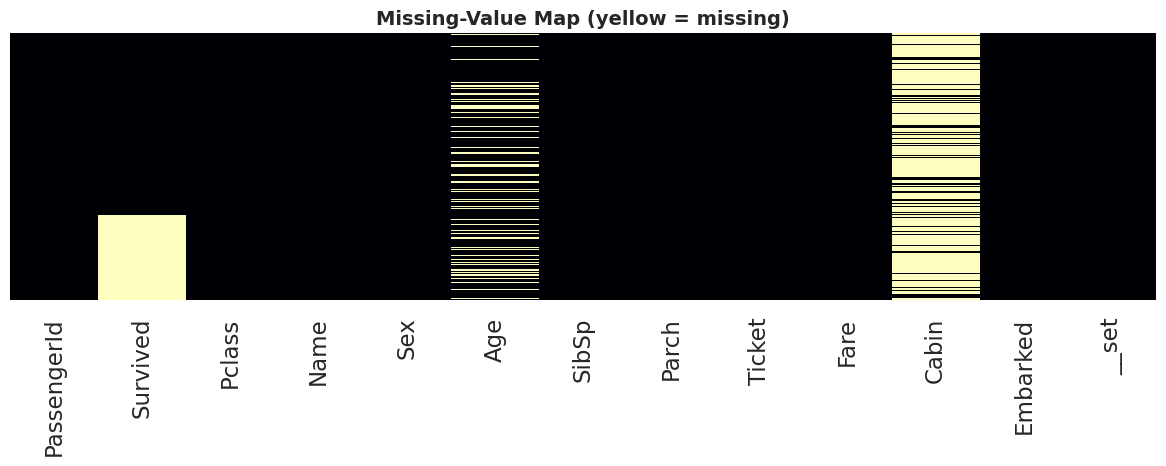

,missing,pct
Cabin,1014,77.460
Survived,418,31.930
Age,263,20.090
Embarked,2,0.150
Fare,1,0.080


In [5]:
# Missing-value heatmap
fig, ax = plt.subplots(figsize=(12,5))
sns.heatmap(full.isna(), cbar=False, yticklabels=False, cmap="magma", ax=ax)
ax.set_title("Missing-Value Map (yellow = missing)")
plt.tight_layout(); plt.show()

# Tabular summary
(full.isna().sum().to_frame("missing")
    .assign(pct=lambda d: (d["missing"]/len(full)*100).round(2))
    .query("missing > 0").sort_values("missing", ascending=False))

In [6]:
# Engineering a Title column
full["Title"] = full["Name"].str.extract(r",\s*([^\.]+)\.")
full["Title"] = full["Title"].str.strip()

# Consolidate rare titles
rare = full["Title"].value_counts()[full["Title"].value_counts() < 10].index
full["Title"] = full["Title"].replace(rare, "Rare")
full["Title"] = full["Title"].replace({"Mlle":"Miss","Ms":"Miss","Mme":"Mrs"})
full["Title"].value_counts()

Title
Mr        757
Miss      260
Mrs       197
Master     61
Rare       34
Name: count, dtype: int64

In [7]:
# Impute Age with group median
full["Age"] = full.groupby(["Pclass","Sex","Title"])["Age"].transform(lambda s: s.fillna(s.median()))

# Fallback if any NaN remains
full["Age"] = full["Age"].fillna(full["Age"].median())

# Impute Fare & Embarked
full["Fare"] = full.groupby("Pclass")["Fare"].transform(lambda s: s.fillna(s.median()))
full["Embarked"] = full["Embarked"].fillna(full["Embarked"].mode()[0])

# Cabin → Deck
full["Deck"] = full["Cabin"].astype(str).str[0].replace("n","U")  # U = Unknown
full["HasCabin"] = full["Cabin"].notna().astype(int)

# Family features
full["FamilySize"] = full["SibSp"] + full["Parch"] + 1
full["IsAlone"] = (full["FamilySize"] == 1).astype(int)

# Tickets / counts
full["TicketPrefix"] = (full["Ticket"].str.replace(r"[^A-Za-z]","", regex=True)
                                   .replace("", "NONE"))

print("Imputation & feature engineering complete")
print("Remaining missing values per column:")
print(full.isna().sum()[full.isna().sum()>0])

Imputation & feature engineering complete
Remaining missing values per column:
Survived     418
Cabin       1014
dtype: int64


## 3. Univariate profiling

Re-split engineered data back to train for supervised analysis.

In [8]:
df = full[full["__set"]=="train"].copy()
df["Survived_lbl"] = df["Survived"].map({0:"Died",1:"Survived"})
print(f"Working analysis frame: {df.shape}")

Working analysis frame: (891, 20)


***Note: Although the Titanic historically carried approximately 1,317 passengers and 885 crew members, this exploratory analysis focuses on the 891 passengers in the training dataset (***`train.csv`***). The other 418 passengers (***`test.csv`***) are excluded because their survival status is unknown (reserved for predictive modeling). The crew is not included in this database. The conclusions drawn here are therefore representative of a highly reliable sample (68% of the actual passenger manifest).***

### 3.1. Target distribution

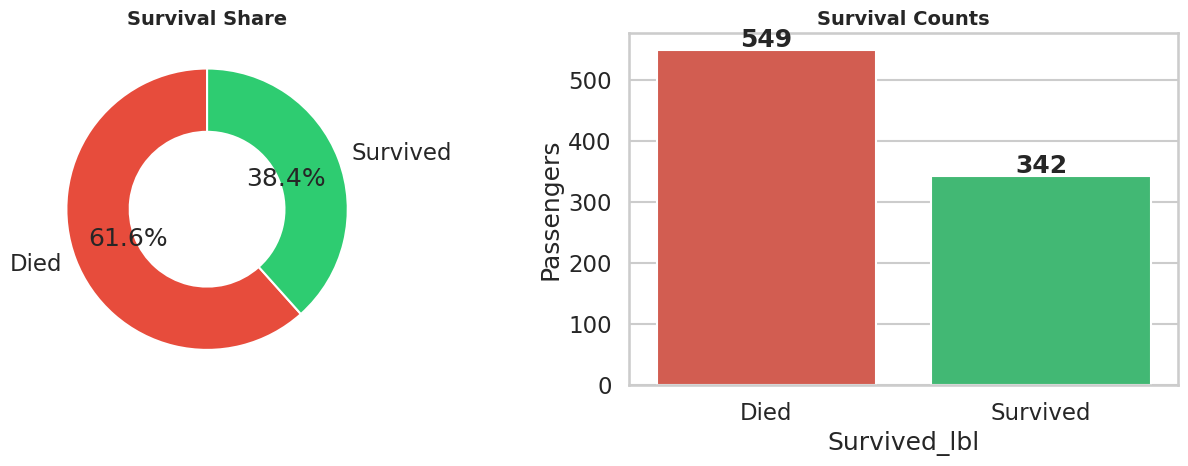

Overall survival rate: 38.4%  (342.0 / 891)


In [9]:
fig, ax = plt.subplots(1,2, figsize=(13,5))
counts = df["Survived_lbl"].value_counts()
ax[0].pie(counts, labels=counts.index, autopct="%1.1f%%",
          colors=[PALETTE["Died"],PALETTE["Survived"]], startangle=90, wedgeprops=dict(width=0.45))
ax[0].set_title("Survival Share")

sns.countplot(data=df, x="Survived_lbl", palette=[PALETTE["Died"],PALETTE["Survived"]], ax=ax[1])
for i,v in enumerate(counts): ax[1].text(i, v+5, str(v), ha="center", fontweight="bold")
ax[1].set_title("Survival Counts"); ax[1].set_ylabel("Passengers")
plt.tight_layout(); plt.show()

overall_rate = df["Survived"].mean()
print(f"Overall survival rate: {overall_rate:.1%}  ({df['Survived'].sum()} / {len(df)})")

***Interpretation:*** Of 891 training passengers, **38.4% survived**.

### 3.2. Categorical feature distributions

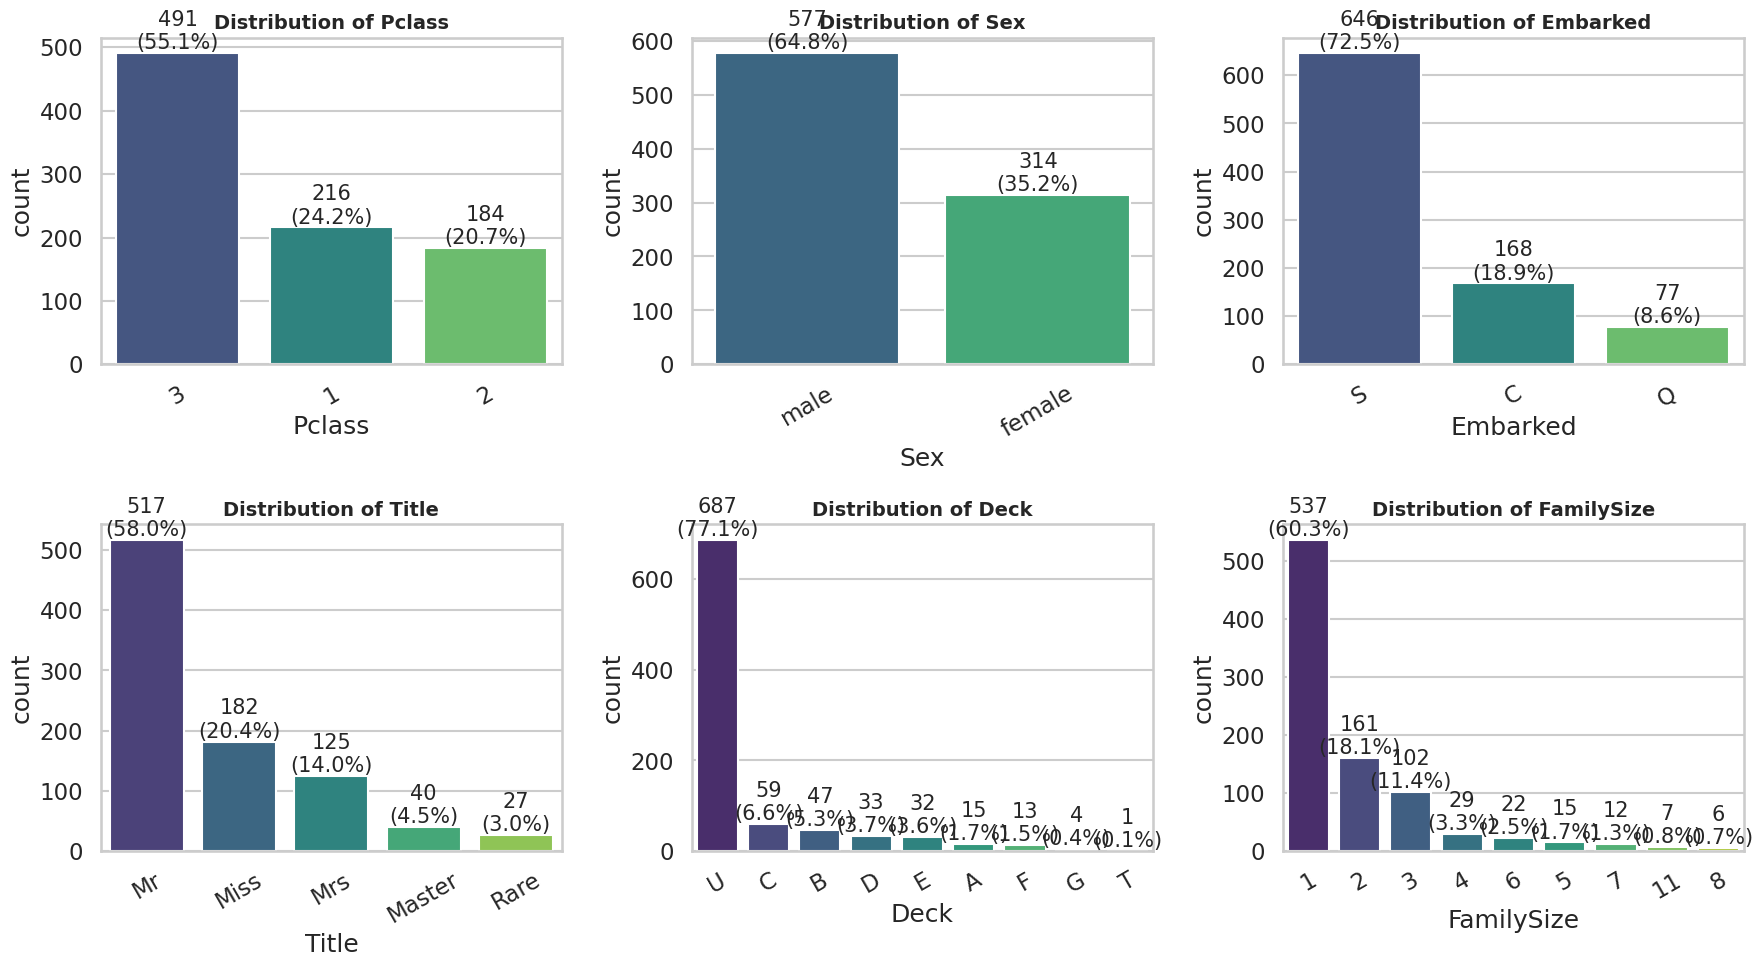

In [10]:
cat_cols = ["Pclass","Sex","Embarked","Title","Deck","FamilySize"]
fig, axes = plt.subplots(2,3, figsize=(18,10))

total = len(df)

for i, ax in enumerate(axes.ravel()):
    if i < len(cat_cols):
        col = cat_cols[i]
        order = df[col].value_counts().index
        sns.countplot(data=df, x=col, order=order, ax=ax, palette="viridis")
        ax.set_title(f"Distribution of {col}")
        ax.tick_params(axis="x", rotation=30)
        
        for p in ax.patches:
            count = int(p.get_height())
            pct = 100 * count / total
            ax.annotate(f"{count}\n({pct:.1f}%)", 
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha="center", va="bottom", fontsize=15)

plt.tight_layout(); plt.show()

***Interpretation:***
- **Pclass:** 3rd-class dominates. Titanic was economically bottom-heavy.
- **Sex:** 64.7% male.
- **Embarked:** Southampton (S - 72.44%) is by far the dominant port. Note that C refers to Cherbourg, and Q to Queenstown. 
- **Title:** "Mr" is the largest group; "Rare" includes honorifics like Dr, Rev, Col, Capt, Lady.
- **Deck:** Unknown deck (U) is the largest bucket due to cabin sparsity.
- **FamilySize:** Solo travellers dominate, with a long tail of large families.

***Note:*** *The Titanic had nine metal decks (A through G) plus the upper decks. Here's what they correspond to, from top (closest to the lifeboats) to bottom (closest to the hull):*
- *T: Boat Deck. This is where the lifeboats were located. Very few luxury cabins were found here.*
- *A: Promenade Deck. Reserved for First Class.*
- *B, C, D, E: These are the main decks. Decks B, C, and D housed the most luxurious First Class cabins and suites (in the center of the ship). Deck D ("Saloon Deck") also contained the grand First Class dining room. Deck E ("Upper Deck") marked the transition, with First, Second, and Third Class cabins, as well as crew quarters.*
- *F: Middle Deck. Primarily 2nd and 3rd class, plus the galleys.*
- *G: Lower Deck. The lowest deck accessible to passengers. Almost exclusively 3rd class (located very close to the waterline and the boiler room crews).*
- *And the "U"? In our code, we created the category U (Unknown) for all passengers who did not have a cabin number recorded in the dataset (the* `cabin` *column was empty 77.1% of the time, as shown in the graphic).*

### 3.3. Numeric feature distributions

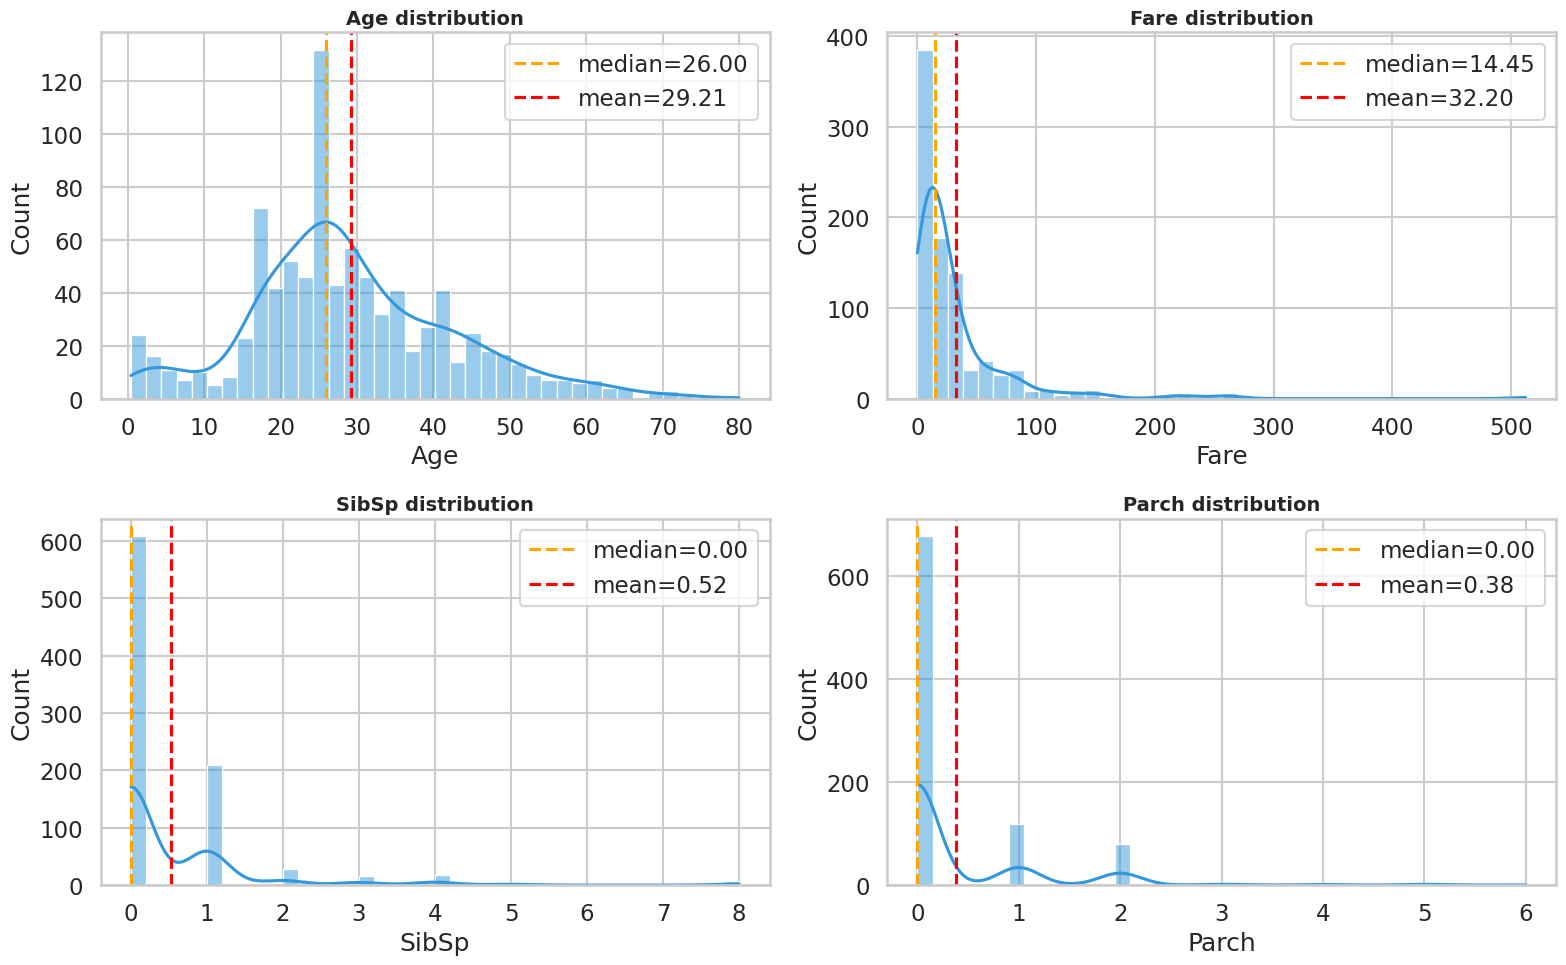

,count,mean,std,min,25%,50%,75%,max
Age,891.000,29.205,13.553,0.420,21.000,26.000,36.750,80.000
Fare,891.000,32.204,49.693,0.000,7.910,14.454,31.000,512.329
SibSp,891.000,0.523,1.103,0.000,0.000,0.000,1.000,8.000
Parch,891.000,0.382,0.806,0.000,0.000,0.000,0.000,6.000


In [11]:
num_cols = ["Age","Fare","SibSp","Parch"]
fig, axes = plt.subplots(2,2, figsize=(16,10))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col].dropna(), kde=True, color="#3498db", bins=40, ax=ax)
    ax.axvline(df[col].median(), color="orange", linestyle="--", label=f"median={df[col].median():.2f}")
    ax.axvline(df[col].mean(),   color="red",    linestyle="--", label=f"mean={df[col].mean():.2f}")
    ax.set_title(f"{col} distribution"); ax.legend()
plt.tight_layout(); plt.show()

df[num_cols].describe().T

***Interpretation:***
- **Age:** Peak around 20-30, plus a children bump under 10. Mean = 29.20 (after imputation). Right-skew is mild.
- **Fare:** Heavily right-skewed (median 14.45 vs mean 32.20). A few first-class suites exceeded 500.
- **SibSp / Parch:** Mostly 0 (solo) or small (1,2, 3, 4). Tail values up to 8 represent large families. They had historically low survival (For example, Sage family lost all 11).

## 4. Bivariate survival analysis

### 4.1. Survival by sex (the headline gap)

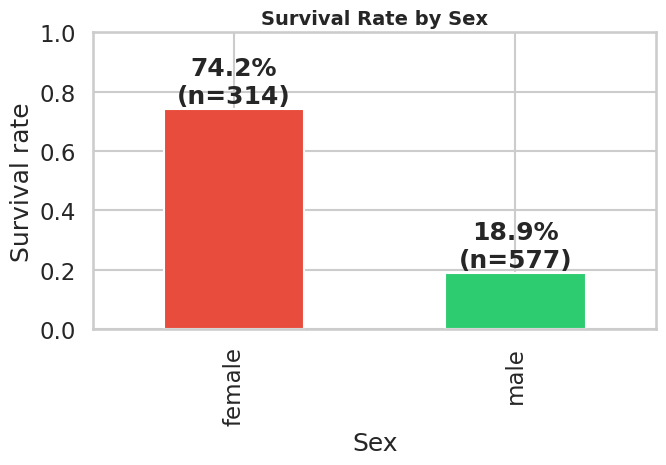

,mean,count
Sex,,
female,0.742,314
male,0.189,577


In [12]:
g = df.groupby("Sex")["Survived"].agg(["mean","count"])
g["mean"].plot(kind="bar", color=["#e74c3c","#2ecc71"], figsize=(7,5))
plt.title("Survival Rate by Sex"); plt.ylabel("Survival rate"); plt.ylim(0,1)
for i,(m,c) in enumerate(zip(g["mean"], g["count"])):
    plt.text(i, m+0.02, f"{m:.1%}\n(n={c})", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()
g

***Interpretation:*** Females survived at **74.2%** vs males at **18.9%** (a **55-point gender gap**). The "women and children first" protocol visibly dominated outcomes.

### 4.2 Survival by passenger class

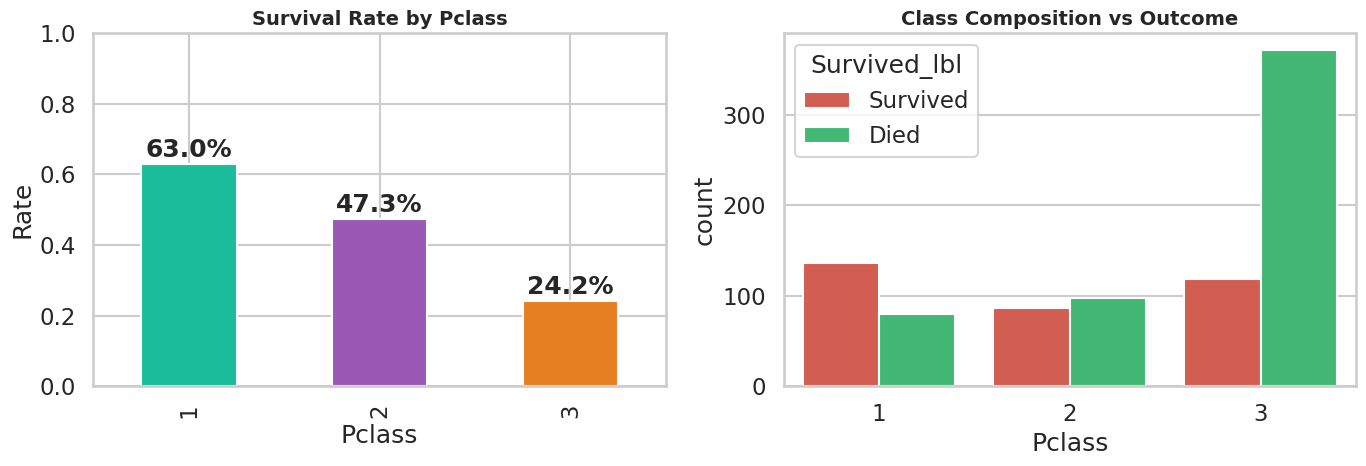

,mean,count,sum
Pclass,,,
1,0.630,216,136.000
2,0.473,184,87.000
3,0.242,491,119.000


In [13]:
fig, ax = plt.subplots(1,2, figsize=(14,5))
class_tab = df.groupby("Pclass")["Survived"].mean()
class_tab.plot(kind="bar", color=["#1abc9c","#9b59b6","#e67e22"], ax=ax[0])
ax[0].set_title("Survival Rate by Pclass"); ax[0].set_ylabel("Rate"); ax[0].set_ylim(0,1)
for i,v in enumerate(class_tab): ax[0].text(i, v+0.02, f"{v:.1%}", ha="center", fontweight="bold")

sns.countplot(data=df, x="Pclass", hue="Survived_lbl",
              palette=[PALETTE["Died"],PALETTE["Survived"]], ax=ax[1])
ax[1].set_title("Class Composition vs Outcome")
plt.tight_layout(); plt.show()

df.groupby("Pclass")["Survived"].agg(["mean","count","sum"])

***Interpretation:*** Survival declines monotonically with class: **1st = 63%, 2nd = 47%, 3rd = 24%**.

### 4.3. Sex x Class interaction

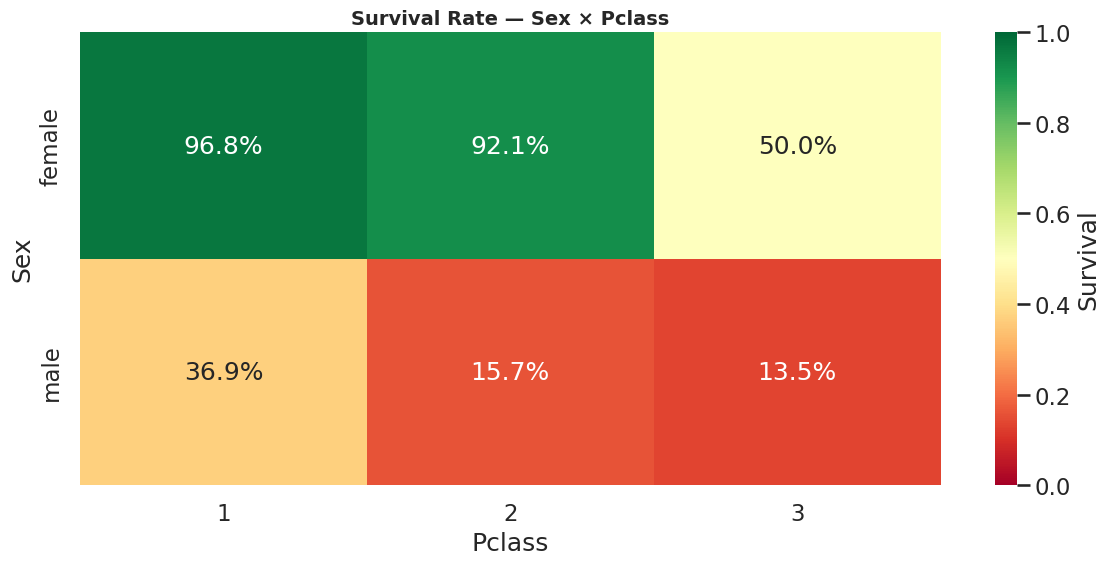

Pclass,1,2,3
Sex,,,
female,0.968,0.921,0.500
male,0.369,0.157,0.135


In [14]:
pivot = df.pivot_table(index="Sex", columns="Pclass", values="Survived", aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".1%", cmap="RdYlGn", vmin=0, vmax=1, cbar_kws={"label":"Survival"})
plt.title("Survival Rate — Sex × Pclass"); plt.tight_layout(); plt.show()
pivot

***Interpretation:*** The interaction is striking:
- 1st & 2nd-class **females**: 96.8% & 92.1% survival - near-universal rescue.
- 3rd-class **females**: only 50% - class overrode gender for poorer women.
- 1st-class **males** (36.9%) still out-survived 3rd-class males (13.5%).

### 4.4. Survival by age

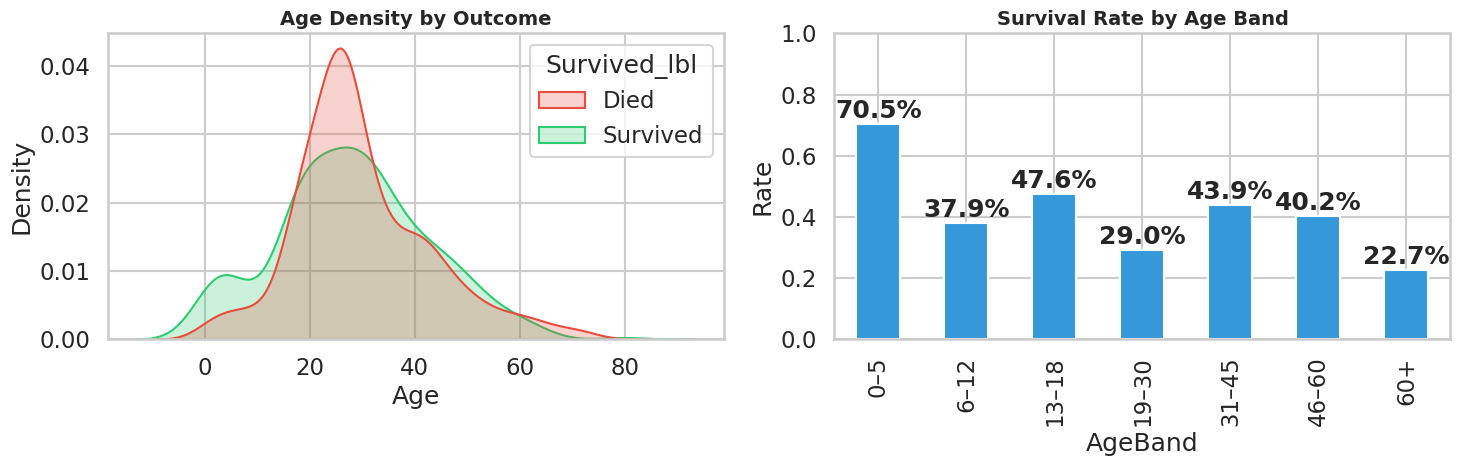

AgeBand
0–5     0.705
6–12    0.379
13–18   0.476
19–30   0.290
31–45   0.439
46–60   0.402
60+     0.227
Name: Survived, dtype: float64

In [15]:
fig, ax = plt.subplots(1,2, figsize=(15,5))
sns.kdeplot(data=df, x="Age", hue="Survived_lbl", fill=True, common_norm=False,
            palette=[PALETTE["Died"],PALETTE["Survived"]], ax=ax[0])
ax[0].set_title("Age Density by Outcome")

age_band = pd.cut(df["Age"], bins=[0,5,12,18,30,45,60,100],
                  labels=["0–5","6–12","13–18","19–30","31–45","46–60","60+"])
band_rate = df.assign(AgeBand=age_band).groupby("AgeBand")["Survived"].mean()
band_rate.plot(kind="bar", color="#3498db", ax=ax[1])
ax[1].set_title("Survival Rate by Age Band"); ax[1].set_ylim(0,1); ax[1].set_ylabel("Rate")
for i,v in enumerate(band_rate): ax[1].text(i, v+0.02, f"{v:.1%}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()
band_rate

***Interpretation:*** Children 0-5 had the highest survival (70.5%), validating the "children first" protocol. Seniors (60+) had the lowest (22.7%), possibly due to reduced mobility. The 19-30 male bulge drove the largest absolute loss.

### 4.5. Survival by fare (log-scaled)

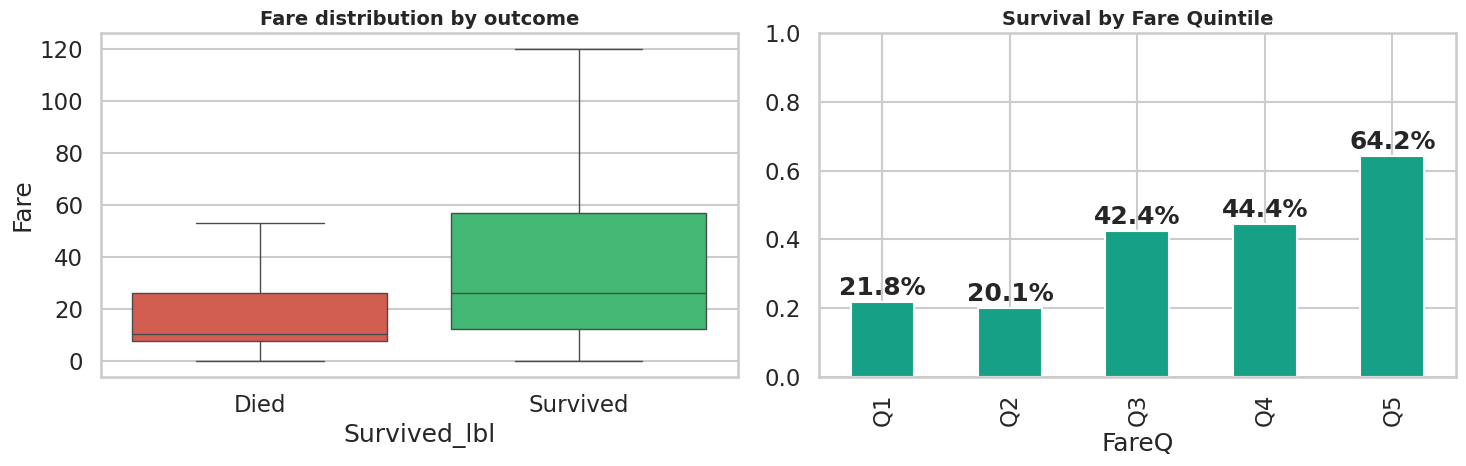

FareQ
Q1   0.218
Q2   0.201
Q3   0.424
Q4   0.444
Q5   0.642
Name: Survived, dtype: float64

In [16]:
fig, ax = plt.subplots(1,2, figsize=(15,5))
sns.boxplot(data=df, x="Survived_lbl", y="Fare", 
            palette=[PALETTE["Died"],PALETTE["Survived"]], ax=ax[0], showfliers=False)
ax[0].set_title("Fare distribution by outcome")

fare_q = pd.qcut(df["Fare"], 5, labels=["Q1","Q2","Q3","Q4","Q5"])
fq_rate = df.assign(FareQ=fare_q).groupby("FareQ")["Survived"].mean()
fq_rate.plot(kind="bar", color="#16a085", ax=ax[1])
ax[1].set_title("Survival by Fare Quintile"); ax[1].set_ylim(0,1)
for i,v in enumerate(fq_rate): ax[1].text(i, v+0.02, f"{v:.1%}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()
fq_rate

***Interpretation:*** This graph compares the distribution of prices paid by those who survived and those who died. It demonstrates a strong monotonic relationship between economic status and the chances of survival. Survivors generally paid significantly more for tickets than the victims. By dividing the prices into quintiles, a clear gradient emerges where the survival rate increases from approximately 21.8% for the cheapest tickets (Q1) to nearly 64.2% for the most luxurious (Q5). Ticket price thus acts as a continuous proxy for social class and cabin location on the ship. Indeed, higher fares bought access to the upper decks, located in the immediate vicinity of the lifeboats, providing a decisive evacuation advantage.

### 4.6. Survival by embarkation port

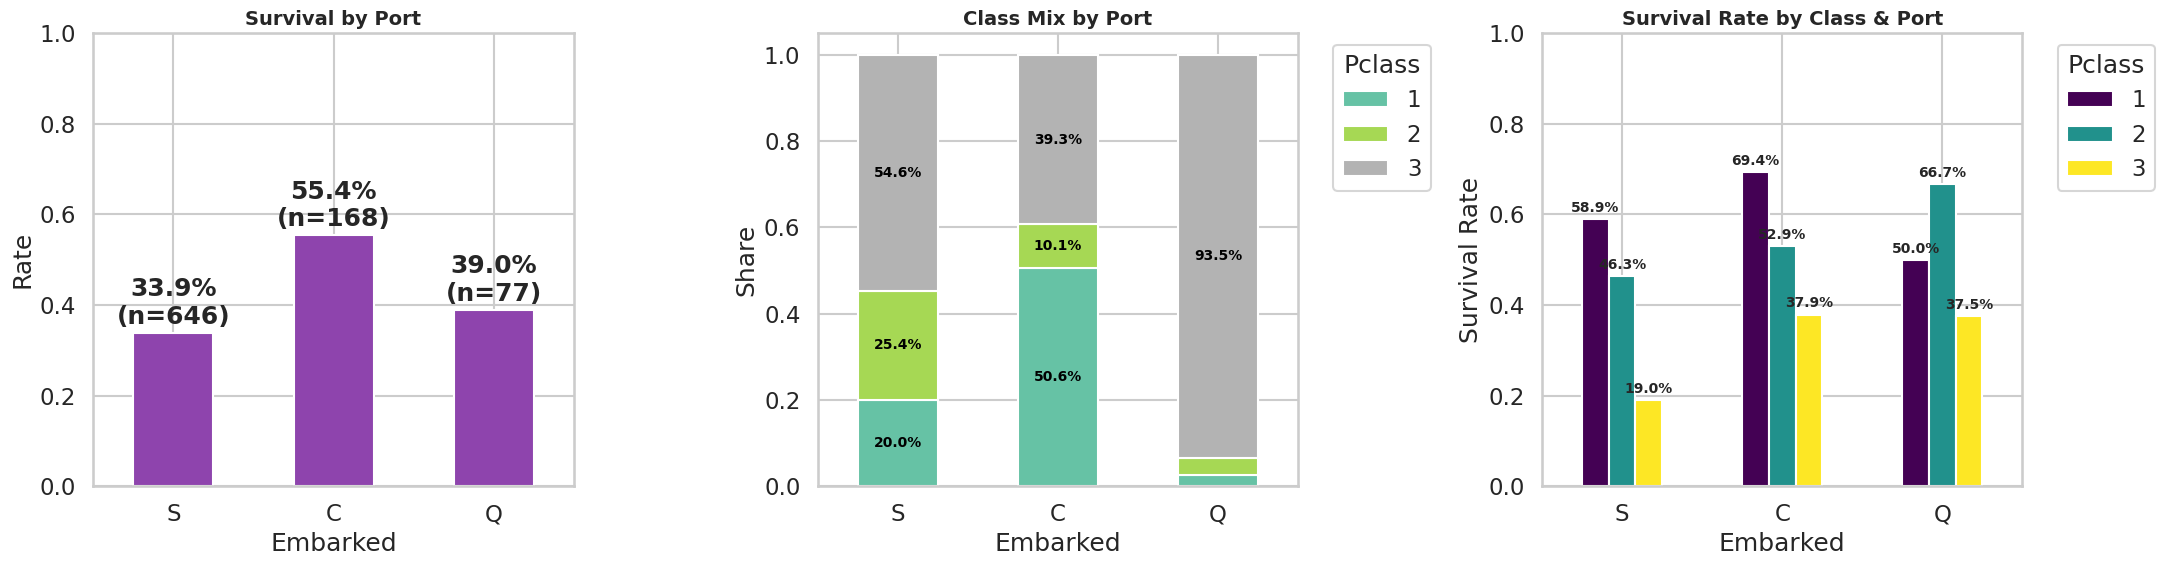

,mean,count
Embarked,,
C,0.554,168
Q,0.390,77
S,0.339,646


In [17]:
port_rate = df.groupby("Embarked")["Survived"].agg(["mean","count"])
fig, ax = plt.subplots(1, 3, figsize=(22, 6))
port_rate["mean"].loc[["S", "C", "Q"]].plot(kind="bar", color="#8e44ad", ax=ax[0])
ax[0].set_title("Survival by Port")
ax[0].set_ylim(0, 1)
ax[0].set_ylabel("Rate")
ax[0].tick_params(axis='x', rotation=0)
for i, (p, v) in enumerate(port_rate.loc[["S", "C", "Q"]].iterrows()):
    ax[0].text(i, v["mean"] + 0.02, f"{v['mean']:.1%}\n(n={int(v['count'])})", 
               ha="center", fontweight="bold")

port_class = df.groupby(["Embarked", "Pclass"]).size().unstack().loc[["S", "C", "Q"]]
port_class_pct = port_class.div(port_class.sum(axis=1), axis=0)
port_class_pct.plot(kind="bar", stacked=True, ax=ax[1], colormap="Set2")
ax[1].set_title("Class Mix by Port")
ax[1].set_ylabel("Share")
ax[1].tick_params(axis='x', rotation=0)
for c in ax[1].containers:
    labels = [f'{v.get_height()*100:.1f}%' if v.get_height() > 0.05 else '' for v in c]
    ax[1].bar_label(c, labels=labels, label_type='center', color='black', fontweight='bold', fontsize=10)
ax[1].legend(title="Pclass", bbox_to_anchor=(1.05, 1), loc='upper left')

pivot_survival = df.pivot_table(index="Embarked", columns="Pclass", values="Survived", aggfunc="mean").loc[["S", "C", "Q"]]
pivot_survival.plot(kind="bar", ax=ax[2], colormap="viridis")
ax[2].set_title("Survival Rate by Class & Port")
ax[2].set_ylabel("Survival Rate")
ax[2].set_ylim(0, 1)
ax[2].tick_params(axis='x', rotation=0)

for container in ax[2].containers:
    labels = [f'{v.get_height():.1%}' if not pd.isna(v.get_height()) else '' for v in container]
    ax[2].bar_label(container, labels=labels, label_type='edge', padding=3, fontweight='bold', fontsize=10)
ax[2].legend(title="Pclass", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

port_rate

***Interpretation:***
- Cherbourg (C) had the highest survival (55.4%), but this is confounded by class: Cherbourg had a disproportionate share of 1st-class passengers (50.6%).
- Southampton (S) is mostly 3rd-class (93.5%), explaining its 33.9% survival.
- In general, for third class, the survival rate is low everywhere, but it varies slightly depending on the port of embarkation. This confirms that the port is merely a proxy (a surrogate variable): it is the class (and not the port itself) that dictates the chances of survival.

### 4.7. Family size

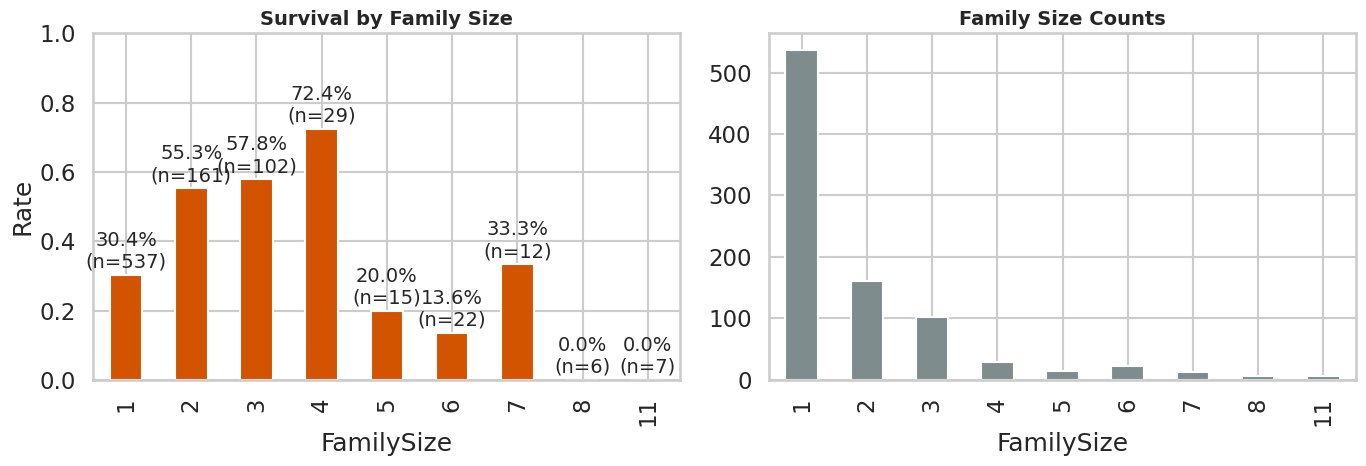

,mean,count
FamilySize,,
1,0.304,537
2,0.553,161
3,0.578,102
4,0.724,29
5,0.200,15
6,0.136,22
7,0.333,12
8,0.000,6
11,0.000,7


In [18]:
fam_rate = df.groupby("FamilySize")["Survived"].agg(["mean","count"])
fig, ax = plt.subplots(1,2, figsize=(14,5))
fam_rate["mean"].plot(kind="bar", color="#d35400", ax=ax[0])
ax[0].set_title("Survival by Family Size"); ax[0].set_ylim(0,1); ax[0].set_ylabel("Rate")
for i,(s,v) in enumerate(fam_rate.iterrows()):
    ax[0].text(i, v["mean"]+0.02, f"{v['mean']:.1%}\n(n={int(v['count'])})", ha="center", fontsize=14)

df.groupby("FamilySize")["Survived"].count().plot(kind="bar", color="#7f8c8d", ax=ax[1])
ax[1].set_title("Family Size Counts")
plt.tight_layout(); plt.show()
fam_rate

***Interpretation:*** Solo travellers (30.4%) and families ≥5 fared worst, while families of 2-4 had 50-70% survival.

## 5. Multivariate & Segment interaction analysis

### 5.1. Survival by Class x Family size

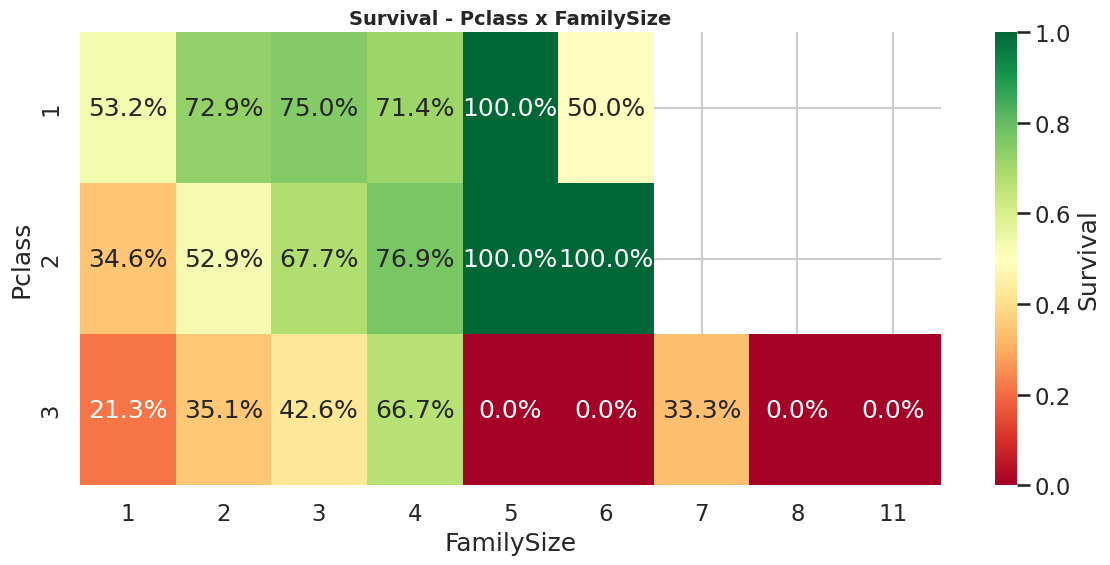

In [19]:
pv = df.pivot_table(index="Pclass", columns="FamilySize", values="Survived", aggfunc="mean")
sns.heatmap(pv, annot=True, fmt=".1%", cmap="RdYlGn", vmin=0, vmax=1, cbar_kws={"label":"Survival"})
plt.title("Survival - Pclass x FamilySize"); plt.tight_layout(); plt.show()

***Interpretation:*** This distribution shows some evidence. 1st-class family-of-5 cell (100% survival) shows that small wealthy groups essentially all made it. Conversely, 3rd-class large families form had a very weak survival rate. 

### 5.2. Age x Sex survival surface

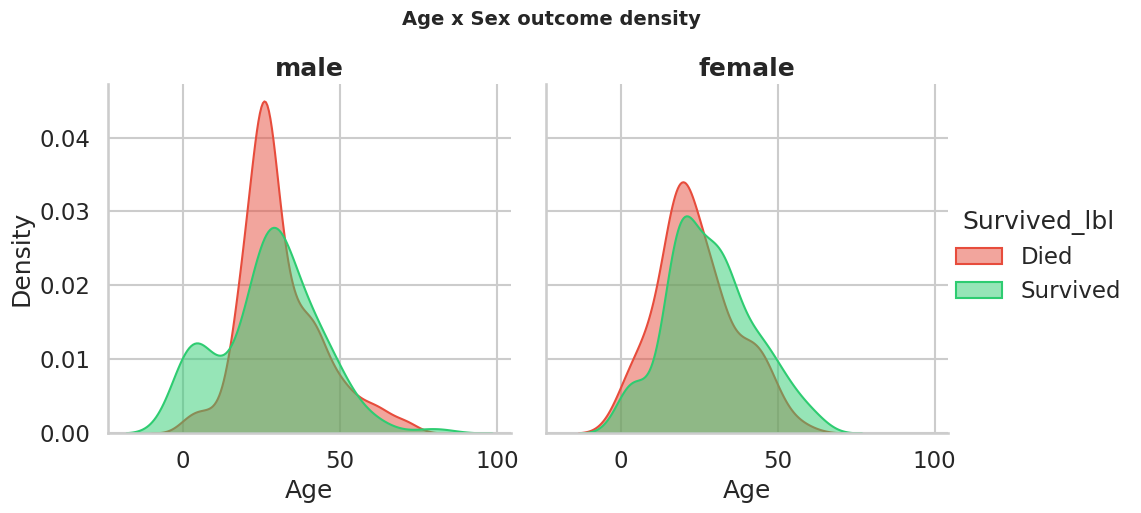

In [20]:
g = sns.FacetGrid(df, col="Sex", hue="Survived_lbl", height=5, palette=[PALETTE["Died"],PALETTE["Survived"]])
g.map_dataframe(sns.kdeplot, x="Age", fill=True, common_norm=False, alpha=0.5)
g.add_legend(); g.set_titles("{col_name}")
g.fig.suptitle("Age x Sex outcome density", y=1.04, fontsize=14, fontweight="bold")
plt.show()

***Interpretation*** For males, the survival density peaks in childhood then collapses through adulthood. For females, survival dominates across all ages - confirming that "children first" was applied on top of "women first", not as a substitute.

### 5.3. Title x Pclass survival grid

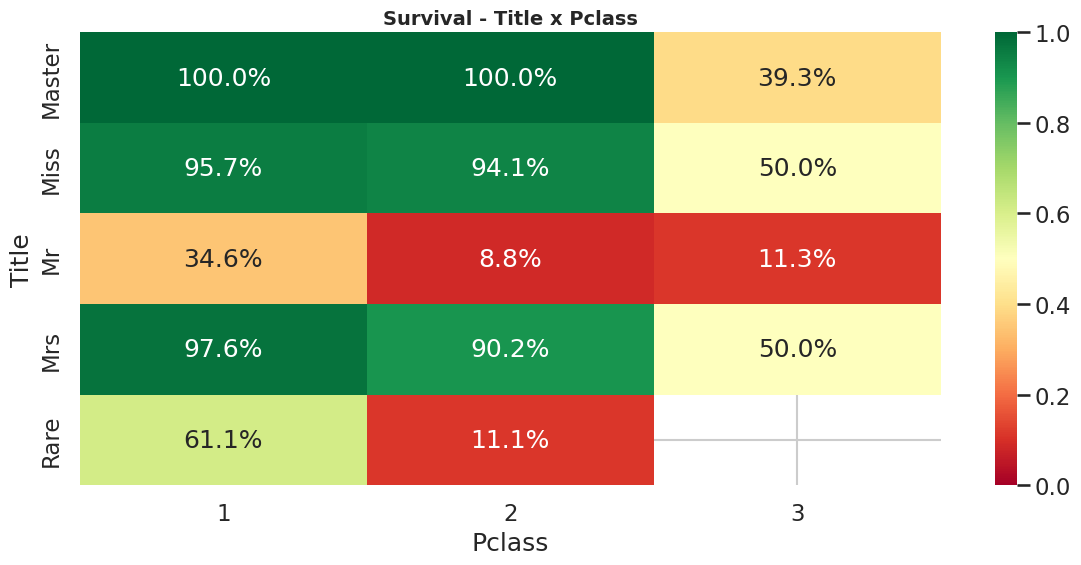

In [21]:
pv2 = df.pivot_table(index="Title", columns="Pclass", values="Survived", aggfunc="mean")
sns.heatmap(pv2, annot=True, fmt=".1%", cmap="RdYlGn", vmin=0, vmax=1)
plt.title("Survival - Title x Pclass"); plt.tight_layout(); plt.show()

***Interpretation:*** "Mrs" and "Miss" titles in 1st/2nd class (90-95%). The protocol was near-absolute for high-status women. "Master" (boys) also performed well (79.76% overall).

## 6. Feature engineering

In [22]:
engineered = df.copy()
engineered["AgeBand"]   = pd.cut(engineered["Age"], bins=[0,5,12,18,30,45,60,100],
                                  labels=["0–5","6–12","13–18","19–30","31–45","46–60","60+"])
engineered["FareBand"]  = pd.qcut(engineered["Fare"], 4, labels=["Low","Mid","High","Premium"])
engineered["FamilyType"]= pd.cut(engineered["FamilySize"], [-1,1,4,11],
                                  labels=["Solo","Small","Large"])

# Quick KPI panel
panel = engineered.groupby(["Pclass","Sex","FamilyType"])["Survived"].agg(["mean","count"]).round(3)
panel.head(20)

mean  count
Pclass Sex    FamilyType             
1      female Solo       0.971     34
              Small      0.964     56
              Large      1.000      4
       male   Solo       0.333     75
              Small      0.444     45
              Large      0.000      2
2      female Solo       0.906     32
              Small      0.929     42
              Large      1.000      2
       male   Solo       0.097     72
              Small      0.278     36
              Large        NaN      0
3      female Solo       0.617     60
              Small      0.561     57
              Large      0.111     27
       male   Solo       0.121    264
              Small      0.250     56
              Large      0.037     27

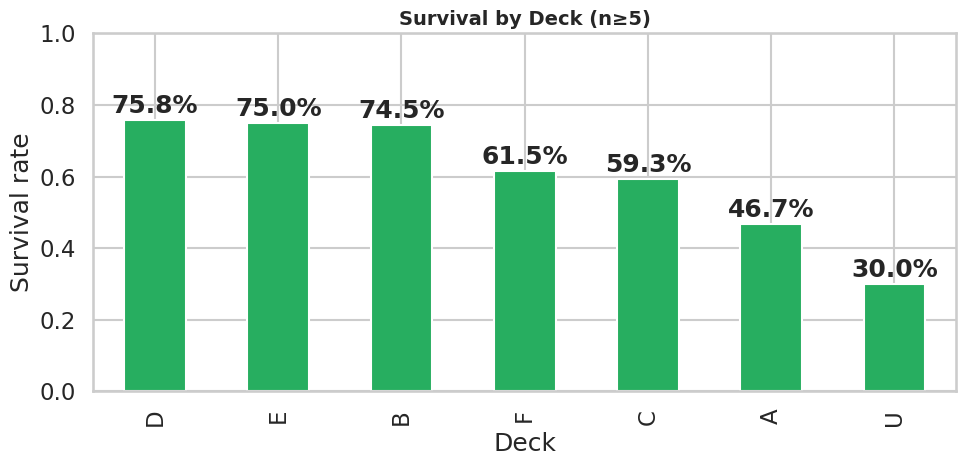

,mean,count
Deck,,
D,0.758,33
E,0.750,32
B,0.745,47
F,0.615,13
C,0.593,59
A,0.467,15
U,0.300,687


In [23]:
# Deck survival
df["Deck"] = df["Cabin"].fillna("U").astype(str).str[0]
deck_rate = df.groupby("Deck")["Survived"].agg(["mean","count"]).query("count>=5").sort_values("mean", ascending=False)
deck_rate.plot(kind="bar", y="mean", legend=False, color="#27ae60", figsize=(10,5))
plt.title("Survival by Deck (n≥5)"); plt.ylim(0,1); plt.ylabel("Survival rate")
for i,v in enumerate(deck_rate["mean"]): plt.text(i, v+0.02, f"{v:.1%}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()
deck_rate

***Interpretation:*** Decks B-D (1st class, boat-deck adjacent) show >75% survival. The `U` (unknown cabin) bucket was 30%, confirming missing cabins correlate with poorer passengers.

## 7. Statistical Validation

We now formally test whether observed differences are statistically significant.

In [24]:
def chi2_test(col):
    ct = pd.crosstab(df[col], df["Survived"])
    chi2, p, dof, _ = chi2_contingency(ct)
    return chi2, p, dof

cat_features = ["Pclass","Sex","Embarked","Title","Deck","FamilySize","IsAlone","HasCabin"]
results = []
for c in cat_features:
    chi2, p, dof = chi2_test(c)
    results.append({"Feature":c, "Chi2":chi2, "dof":dof, "p-value":p,
                    "Significant": "✅" if p<0.05 else "❌"})
chi_df = pd.DataFrame(results).sort_values("Chi2", ascending=False)
chi_df

,Feature,Chi2,dof,p-value,Significant
3,Title,283.312,4,0.000,✅
1,Sex,260.717,1,0.000,✅
0,Pclass,102.889,2,0.000,✅
4,Deck,99.164,8,0.000,✅
7,HasCabin,87.941,1,0.000,✅
5,FamilySize,80.672,8,0.000,✅
6,IsAlone,36.001,1,0.000,✅
2,Embarked,25.964,2,0.000,✅


***Interpretation:*** All categorical features are highly significant (p<0.001). Title dominates (χ²=283.31), followed by Sex (=260.71) and Pclass (=102.88).

## 8. Correlation matrix

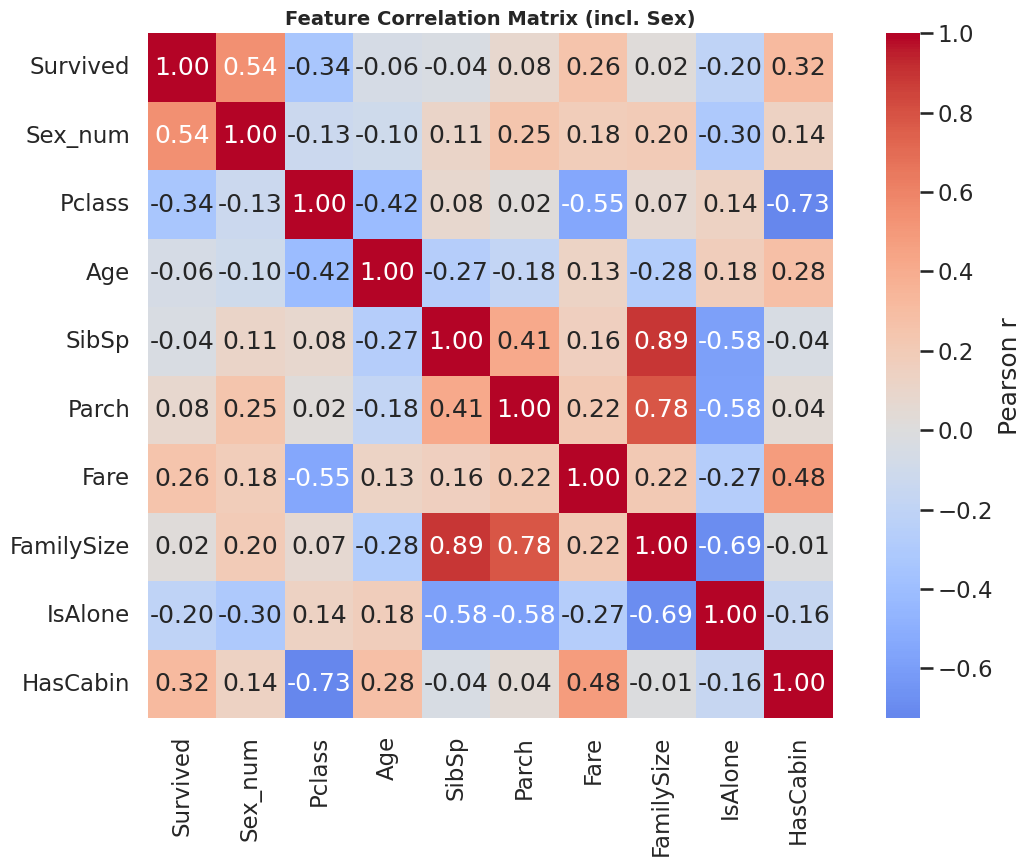

In [25]:
df["Sex_num"] = df["Sex"].map({"male": 0, "female": 1})
corr_cols = ["Survived", "Sex_num", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize", "IsAlone", "HasCabin"]
corr = df[corr_cols].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            cbar_kws={"label": "Pearson r"})
plt.title("Feature Correlation Matrix (incl. Sex)")
plt.tight_layout()
plt.show()

***Interpretation:*** This heatmap presents the Pearson correlation coefficients (r) between the main variables in the dataset. The primary objective here is to identify which factors are linearly related to survival (`Survived`).

Looking at the first row (or column) of `Survived`, we observe that **no variable has an extremely strong linear correlation (close to 1 or -1)**, confirming that **survival is not dictated by a single factor, but by a combination of several**. The key points are:
- `Sex_num` (+0.54): This is the strongest positive correlation. Being female is strongly positively correlated with survival.
- `Pclass` (-0.34): This is the strongest (negative) correlation with survival. The negative sign indicates that the higher the class number (Pclass 3), the lower the survival rate. This is the main marker of socioeconomic status.
- `HasCabin` (+0.32): Strong positive correlation. Simply having a registered cabin number (which is a proxy for 1st/2nd class and proximity to the lifeboat deck) significantly increases the chances of survival.
- `Fare` (+0.26): Moderate positive correlation. The more expensive the ticket, the higher the survival rate. Although related to class, it also captures nuances within the same class (luxury suite vs. standard cabin).
- `IsAlone` (-0.20): Negative correlation. Passengers traveling alone (IsAlone = 1) were at a clear disadvantage compared to those traveling with family.
- `Age` (-0.07): Very weak negative correlation. Linearly, age doesn't explain much. Because the relationship between age and survival is not linear (children were saved first, but many elderly people perished). Pearson's correlation coefficient does not capture this U-shaped relationship.
- `Family Size` (+0.02): Near-zero correlation. Here again, the relationship is not linear (families of 2 to 4 people survived better, but families of 5 or more perished). The linear correlation masks this "Goldilocks" effect (too small or too large = danger).

## 9. Model prediction

### 9.1. Advanced feature engineering

In [26]:
# Title
full['Title'] = full['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
full['Title'] = full['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
full['Title'] = full['Title'].replace('Mlle', 'Miss')
full['Title'] = full['Title'].replace('Ms', 'Miss')
full['Title'] = full['Title'].replace('Mme', 'Mrs')

# FamilySize
full['FamilySize'] = full['SibSp'] + full['Parch'] + 1
full['IsAlone'] = (full['FamilySize'] == 1).astype(int)

# Deck
full['Deck'] = full['Cabin'].fillna('U').astype(str).str[0]
full['HasCabin'] = full['Cabin'].notna().astype(int)

# Ticket
full['Ticket_Freq'] = full.groupby('Ticket')['Ticket'].transform('count')

# Fare
full['FarePerPerson'] = full['Fare'] / full['Ticket_Freq']

# TicketPrefix
full['TicketPrefix'] = full['Ticket'].apply(lambda x: re.sub(r'[^A-Za-z]', '', x).strip() or 'NONE')

print("Features created")

Features created


### 9.2. Intelligent imputation and cleanup

In [27]:
# Imputation of Age by Grouped Median (Pclass & Title)
full['Age'] = full.groupby(['Title', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
full['Age'] = full['Age'].fillna(full['Age'].median()) # Fallback

# Imputation Fare
full['Fare'] = full.groupby(['Pclass', 'Embarked'])['Fare'].transform(lambda x: x.fillna(x.median()))
full['FarePerPerson'] = full['FarePerPerson'].fillna(0)

# Imputation Embarked
full['Embarked'] = full['Embarked'].fillna(full['Embarked'].mode()[0])

# Logarithmic Transformation on Fare
full['Fare'] = np.log1p(full['Fare'])
full['FarePerPerson'] = np.log1p(full['FarePerPerson'])

# Creating age bands (Bins)
full['AgeBin'] = pd.cut(full['Age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])

# Drop unnecessary columns
full = full.drop(['Name', 'Ticket', 'Cabin', 'SibSp', 'Parch', 'PassengerId'], axis=1)

print("Data imputed and cleaned")

Data imputed and cleaned


### 9.3. Encoding of categorical variables

In [28]:
# Encoding One-Hot
categorical = ['Sex', 'Embarked', 'Title', 'Deck', 'TicketPrefix', 'AgeBin']
full = pd.get_dummies(full, columns=categorical, drop_first=True)

# Separation Train / Test
train_proc = full[full['__set'] == 'train'].drop('__set', axis=1)
test_proc = full[full['__set'] == 'test'].drop(['__set', 'Survived'], axis=1)

# Column alignment
test_proc = test_proc.reindex(columns=train_proc.columns, fill_value=0)
test_proc = test_proc.drop('Survived', axis=1)

X = train_proc.drop('Survived', axis=1)
y = train_proc['Survived'].astype(int)
X_test_final = test_proc

print(f"Shape X_train: {X.shape} | Shape X_test: {X_test_final.shape}")

Shape X_train: (891, 59) | Shape X_test: (418, 59)


### 9.4. Modeling and training

In [29]:
# Random Forest

test_ids = test["PassengerId"]

rf = RandomForestClassifier(
    n_estimators=500, max_depth=6, min_samples_leaf=2, 
    max_features='sqrt', random_state=42, n_jobs=-1
)

# Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4, 
    min_samples_leaf=2, random_state=42
)

# Vector Machine Support
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, C=1.0, kernel='rbf', random_state=42))
])

# Logistic regression
logreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(C=0.1, solver='liblinear', random_state=42))
])

# Creation of the assembly model
ensemble_model = VotingClassifier(
    estimators=[
        ('rf', rf), 
        ('gb', gb), 
        ('svm', svm_pipe), 
        ('logreg', logreg_pipe)
    ],
    voting='soft',
    weights=[2, 3, 1, 1]
)

print("Training of the ensemble model on the entire dataset...")
ensemble_model.fit(X, y)
print("✅ Training complete")

predictions = ensemble_model.predict(X_test_final)

submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived': predictions
})

submission.to_csv('submission.csv', index=False)

print("\n📁 'submission.csv' file generated successfully")
print("Predictions overview :")
print(submission.head())

Training of the ensemble model on the entire dataset...
✅ Training complete

📁 'submission.csv' file generated successfully
Predictions overview :
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1


## Conclusion

Through this comprehensive analytical journey, from initial univariate explorations to complex predictive modeling, we have uncovered the critical determinants of survival aboard the Titanic.

The data clearly demonstrates that survival was not merely a game of chance. Distinct passenger profiles, heavily influenced by socio-economic class, sex, and age, were significantly more likely to be spared from the tragedy. 

By quantifying these determining factors, our machine learning models successfully translated historical observations into strong predictive patterns. This EDA not only highlights the stark realities of the disaster but also showcases the power of data analysis and data science in extracting meaningful narratives from raw, historical records.